<a href="https://colab.research.google.com/github/Dr-Isam-ALJAWARNEH/fds-project-geodevelopers/blob/main/clustering_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
%pip install pygeohash

In [6]:
import pandas as pd
import geopandas as gpd
import pygeohash as gh
import numpy as np
from datascience import *
%matplotlib inline
#path_data = '../../../assets/data/'
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from geopy.distance import great_circle
from sklearn.preprocessing import StandardScaler
import time
from scipy.spatial import distance_matrix
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.spatial.distance import pdist, squareform

In [7]:
#Create new dataframe table, and import all available Chicago files in the repositry to it.
Chicago_df_original = Table().to_df()

for i in range(1,20):
  file_link = 'https://raw.githubusercontent.com/IsamAljawarneh/datasets/refs/heads/master/data/Chicago/AQ_data/chicago_eclipse_data_part_'+str(i)+'.csv'
  Chicago_df_original = pd.concat([Chicago_df_original, pd.read_csv(file_link,index_col=False)], ignore_index=True)

Chicago_df_original

,City,DeviceId,LocationName,Latitude,Longitude,ReadingDateTimeUTC,PM25,CalibratedPM25,CalibratedO3,CalibratedNO2,CO,Temperature,Humidity,BatteryLevel,PercentBattery,CellSignal
0,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:03:00,5.561094,NaN,NaN,NaN,0.123580,27.383499,55.128479,4.237187,93.964844,-76.0
1,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:08:10,6.633914,NaN,NaN,NaN,0.132103,27.079086,55.059814,4.236094,93.964844,-81.0
2,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:13:20,4.068707,NaN,NaN,NaN,0.131126,27.079086,55.035400,4.236406,93.964844,-80.0
3,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:18:30,6.351702,NaN,NaN,NaN,0.138784,26.945572,54.632568,4.236094,93.863281,-82.0
4,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:23:40,9.574065,NaN,NaN,NaN,0.413070,26.828079,53.907776,4.235938,93.863281,-81.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2461084,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:29:48,4.479115,10.72,34.66,12.51,0.413648,22.817307,73.245239,4.176250,89.785156,-62.0
2461085,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:34:58,6.322502,14.89,34.71,6.35,0.656208,22.713165,73.222351,4.186875,89.785156,-61.0
2461086,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:40:08,9.796841,13.51,36.71,2.62,0.336273,22.659760,73.472595,4.186250,89.683594,-60.0
2461087,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:45:17,5.173977,11.20,34.33,3.53,0.372924,22.526245,73.468018,4.186250,89.683594,-61.0


In [8]:
Chicago_df_all = Chicago_df_original
Chicago_df_all['ReadingDate'] = pd.to_datetime(Chicago_df_all['ReadingDateTimeUTC'])
Chicago_df_all

,City,DeviceId,LocationName,Latitude,Longitude,ReadingDateTimeUTC,PM25,CalibratedPM25,CalibratedO3,CalibratedNO2,CO,Temperature,Humidity,BatteryLevel,PercentBattery,CellSignal,ReadingDate
0,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:03:00,5.561094,NaN,NaN,NaN,0.123580,27.383499,55.128479,4.237187,93.964844,-76.0,2021-06-20 00:03:00
1,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:08:10,6.633914,NaN,NaN,NaN,0.132103,27.079086,55.059814,4.236094,93.964844,-81.0,2021-06-20 00:08:10
2,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:13:20,4.068707,NaN,NaN,NaN,0.131126,27.079086,55.035400,4.236406,93.964844,-80.0,2021-06-20 00:13:20
3,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:18:30,6.351702,NaN,NaN,NaN,0.138784,26.945572,54.632568,4.236094,93.863281,-82.0,2021-06-20 00:18:30
4,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:23:40,9.574065,NaN,NaN,NaN,0.413070,26.828079,53.907776,4.235938,93.863281,-81.0,2021-06-20 00:23:40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2461084,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:29:48,4.479115,10.72,34.66,12.51,0.413648,22.817307,73.245239,4.176250,89.785156,-62.0,2021-10-03 23:29:48
2461085,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:34:58,6.322502,14.89,34.71,6.35,0.656208,22.713165,73.222351,4.186875,89.785156,-61.0,2021-10-03 23:34:58
2461086,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:40:08,9.796841,13.51,36.71,2.62,0.336273,22.659760,73.472595,4.186250,89.683594,-60.0,2021-10-03 23:40:08
2461087,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:45:17,5.173977,11.20,34.33,3.53,0.372924,22.526245,73.468018,4.186250,89.683594,-61.0,2021-10-03 23:45:17


In [9]:
Chicago_ds_all = Table().from_df(Chicago_df_all)
Chicago_ds_all

City,DeviceId,LocationName,Latitude,Longitude,ReadingDateTimeUTC,PM25,CalibratedPM25,CalibratedO3,CalibratedNO2,CO,Temperature,Humidity,BatteryLevel,PercentBattery,CellSignal,ReadingDate
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:03:00,5.56109,nan,nan,nan,0.12358,27.3835,55.1285,4.23719,93.9648,-76,2021-06-20 00:03:00
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:08:10,6.63391,nan,nan,nan,0.132103,27.0791,55.0598,4.23609,93.9648,-81,2021-06-20 00:08:10
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:13:20,4.06871,nan,nan,nan,0.131126,27.0791,55.0354,4.23641,93.9648,-80,2021-06-20 00:13:20
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:18:30,6.3517,nan,nan,nan,0.138784,26.9456,54.6326,4.23609,93.8633,-82,2021-06-20 00:18:30
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:23:40,9.57407,nan,nan,nan,0.41307,26.8281,53.9078,4.23594,93.8633,-81,2021-06-20 00:23:40
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:28:50,6.02794,nan,nan,nan,0.157761,26.7667,58.0338,4.23609,93.8633,-82,2021-06-20 00:28:50
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:34:00,3.61224,nan,nan,nan,0.115831,26.3367,56.1356,4.23625,93.8633,-81,2021-06-20 00:34:00
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:39:10,3.75591,nan,nan,nan,0.122269,26.2032,55.838,4.22625,93.8633,-81,2021-06-20 00:39:10
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:44:20,6.00689,nan,nan,nan,0.184926,26.1712,55.6427,4.23547,93.8633,-80,2021-06-20 00:44:20
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:49:30,8.50949,nan,nan,nan,0.11234,26.2032,55.4581,4.23609,93.8633,-80,2021-06-20 00:49:30


In [22]:
def cluster_nearby_geohash_points(df_table, pollution_column):
    # Step 1: Filter only valid rows
    subset = df_table.dropna(subset=['Latitude', 'Longitude', pollution_column]).copy()

    # Step 2: Extract and scale features
    features = subset[['Latitude', 'Longitude', pollution_column]].values
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(features)

    # Step 3: Apply DBSCAN
    db = DBSCAN(eps=0.3, min_samples=1)
    labels = db.fit_predict(scaled_features)
    subset['Cluster'] = labels

    # Step 4: Remove noise
    clustered = subset[subset['Cluster'] != -1]

    # Step 5: Compute centroids and average pollution
    centroids = (
        clustered
        .groupby('Cluster')[['Latitude', 'Longitude', pollution_column]]
        .mean()
        .reset_index()
        .rename(columns={pollution_column: f'Avg_{pollution_column}'})
    )

    # Step 6: Plot
    plt.figure(figsize=(10, 8))
    plt.scatter(
        clustered['Longitude'], clustered['Latitude'],
        c='skyblue', s=50, alpha=0.6, label='Sensor Points'
    )

    # Color-coded centroids
    pollution_levels = centroids[f'Avg_{pollution_column}']
    norm = plt.Normalize(pollution_levels.min(), pollution_levels.max())
    cmap = plt.colormaps['YlOrRd']

    scatter = plt.scatter(
        centroids['Longitude'],
        centroids['Latitude'],
        c=pollution_levels,
        cmap=cmap,
        norm=norm,
        s=100,
        marker='X',
        edgecolor='black',
        label='Cluster Centroids (pollution)'
    )

    plt.title("Nearby Clustered Sensor Points", fontsize=14)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # attach colorbar to the scatter plot
    cbar = plt.colorbar(scatter)
    cbar.set_label(f'Avg {pollution_column}')

    plt.show()

    return clustered, centroids


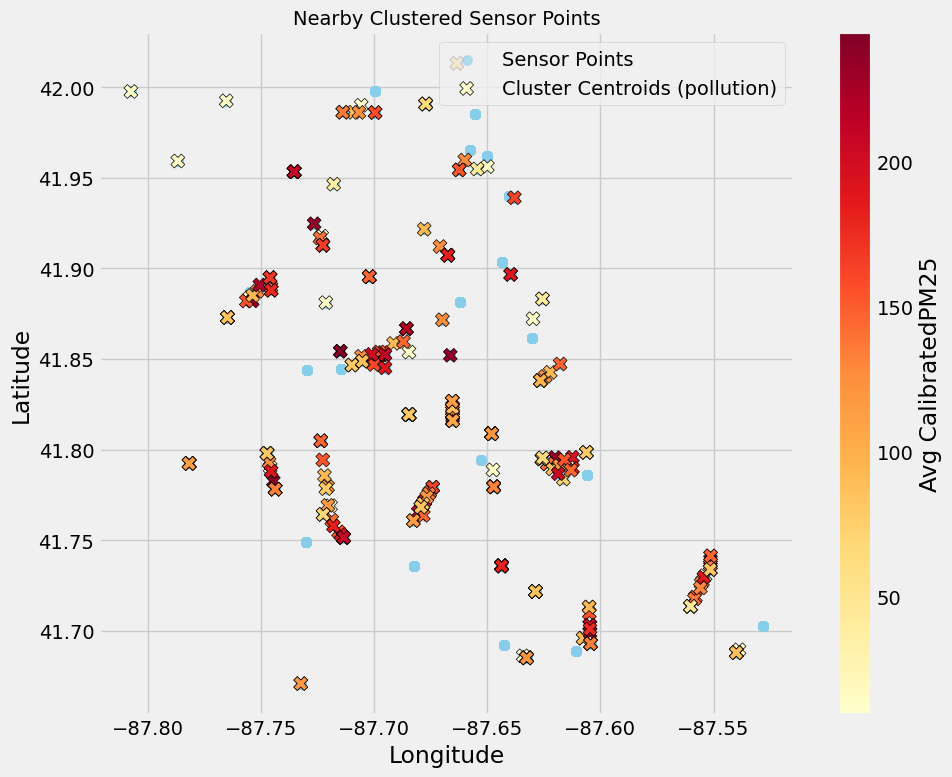

<Figure size 640x480 with 0 Axes>

In [23]:
clustered, centroids = cluster_nearby_geohash_points(Chicago_df_original.head(300000).copy(), 'CalibratedPM25')
plt.tight_layout()
plt.show()